In [1]:
import os

import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats
from astropy.coordinates import SkyCoord
from astropy.io import fits
from gammapy.irf import load_irf_dict_from_file, EnergyDependentMultiGaussPSF
from scipy.stats import chi2, poisson
from scipy.optimize import curve_fit, least_squares

In [2]:
# TODO: change name if needed
name = "Mrk421"
blazar_coord = SkyCoord.from_name(name)
# TODO: change data_folder if needed
data_folder = "../cta_dc_data/mrk_421/"
data_folder_40deg = data_folder+"40deg/"
data_folder_20deg = data_folder+"20deg/"
irf_file_40deg = "../cta_dc_data/irfs/Prod5-North-40deg-AverageAz-4LSTs09MSTs.180000s-v0.1.fits.gz"
irf_file_20deg = "../cta_dc_data/irfs/Prod5-North-20deg-AverageAz-4LSTs09MSTs.180000s-v0.1.fits.gz"

In [3]:
blazar_l = blazar_coord.galactic.l.deg
blazar_b = blazar_coord.galactic.b.deg

hbus_40deg = []
hbus_20deg = []
for filename in os.listdir(data_folder_40deg):
    hbus_40deg.append(fits.open(data_folder_40deg + filename))
for filename in os.listdir(data_folder_20deg):
    hbus_20deg.append(fits.open(data_folder_20deg + filename))
    
irf_40deg = load_irf_dict_from_file(irf_file_40deg)
irf_20deg = load_irf_dict_from_file(irf_file_20deg)
print(f"Pointings 40deg: {len(hbus_40deg)}")
print(f"Pointings 20deg: {len(hbus_20deg)}")

Pointings 40deg: 81
Pointings 20deg: 37


In [4]:
pointing_sep_avg = 0

for hbu in hbus_40deg:
    data_raw = hbu["EVENTS"].data

    pointing_coord = SkyCoord(
        ra=hbu[1].header["RA_PNT"] * u.deg,
        dec=hbu[1].header["DEC_PNT"] * u.deg,
        frame="icrs",
    )
    
    pointing_sep = pointing_coord.separation(blazar_coord).degree
    pointing_sep_avg += pointing_sep

pointing_sep_avg /= len(hbus_40deg)
print(pointing_sep_avg)

0.699999995981589


In [5]:
e_bins=np.logspace(np.log10(0.01), np.log10(10), 15)
e_mins=e_bins[:-1]
e_maxs=e_bins[1:]
e=np.sqrt(e_mins*e_maxs)
de=e_maxs-e_mins

th2_bins=np.linspace(0,pointing_sep_avg**2/4, 100)
th2=(th2_bins[1:]+th2_bins[:-1])/2.

**Data collecting and overview**

In [6]:
def collect_data(hbus):
    cts_s = np.zeros((len(e), len(th2)))
    cts_b = np.zeros((len(e), len(th2)))
    t_expo = 0

    for hbu in hbus:
        data_raw = hbu["EVENTS"].data
    
        t = data_raw["TIME"]
        t = np.sort(t)
        t_expo += t[-1] - t[0]
    
        coord = SkyCoord(
            ra=data_raw["RA"] * u.deg, dec=data_raw["DEC"] * u.deg, frame="icrs"
        )
    
        pointing_coord = SkyCoord(
            ra=hbu[1].header["RA_PNT"] * u.deg,
            dec=hbu[1].header["DEC_PNT"] * u.deg,
            frame="icrs",
        )
    
        bkg_center = SkyCoord(
            l=2 * pointing_coord.galactic.l - blazar_coord.galactic.l,
            b=2 * pointing_coord.galactic.b - blazar_coord.galactic.b,
            frame="galactic",
        )

        seps = coord.separation(blazar_coord).degree
        seps_b = coord.separation(bkg_center).degree
        src_pos_mask = seps < bkg_subtraction_radius
        bkg_pos_mask = seps_b < bkg_subtraction_radius
    
        energ = data_raw["ENERGY"]
    
        for i, (energ_min, energ_max) in enumerate(zip(e_mins, e_maxs)):
            m_s = (energ>energ_min) & (energ<energ_max) & src_pos_mask
            m_b = (energ>energ_min) & (energ<energ_max )& bkg_pos_mask
    
            h_s, _ = np.histogram(seps[m_s]**2, bins=th2_bins)
            h_b, _ = np.histogram(seps_b[m_b]**2, bins=th2_bins)
            
            cts_s[i] += h_s
            cts_b[i] += h_b
    
    return cts_s, cts_b, t_expo

In [7]:
bkg_subtraction_radius = pointing_sep_avg

cts_s_40deg, cts_b_40deg, t_expo_40deg = collect_data(hbus_40deg)
cts_s_20deg, cts_b_20deg, t_expo_20deg = collect_data(hbus_20deg)

print(f"Exposure time 40deg = {t_expo_40deg/60/60:.1f}h")
print(f"Exposure time 20deg = {t_expo_20deg/60/60:.1f}h")

Exposure time 40deg = 11.3h
Exposure time 20deg = 4.9h


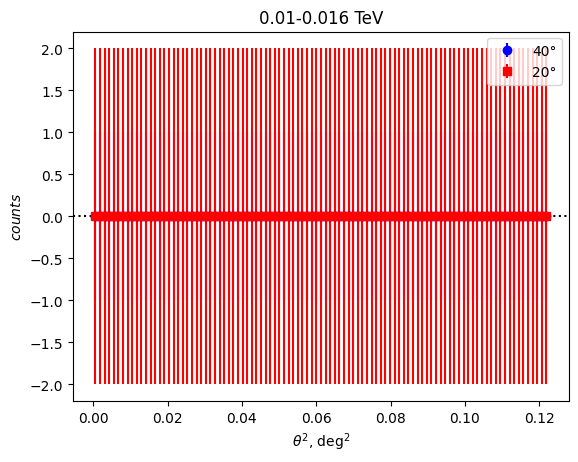

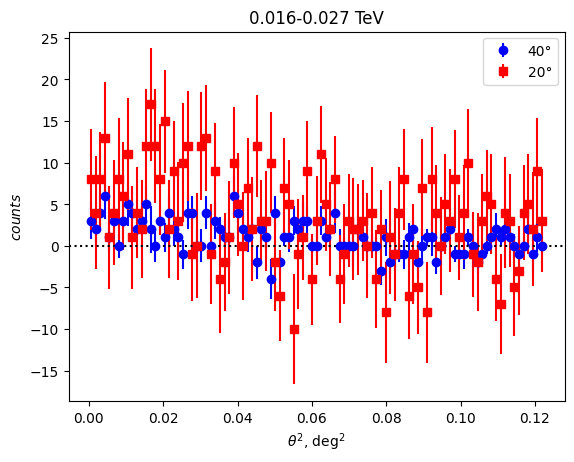

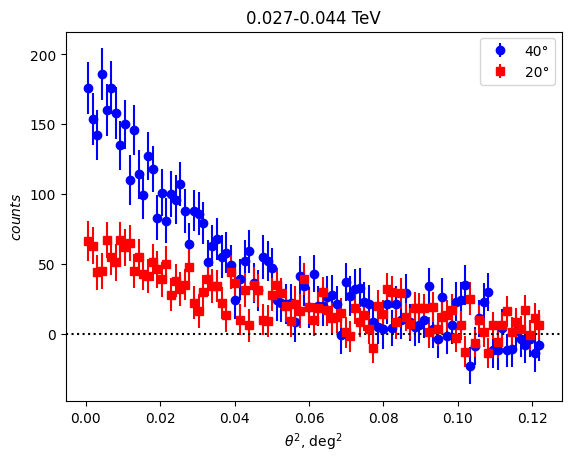

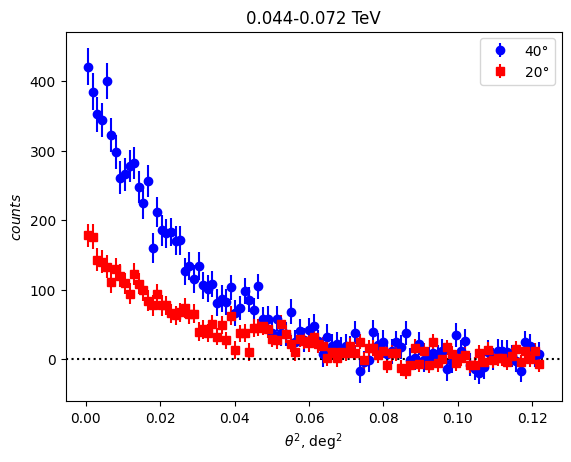

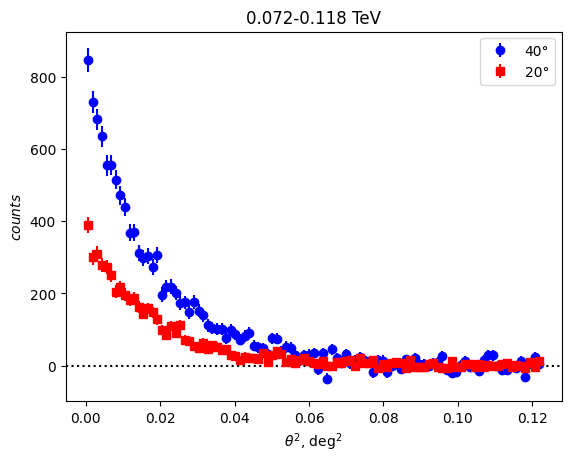

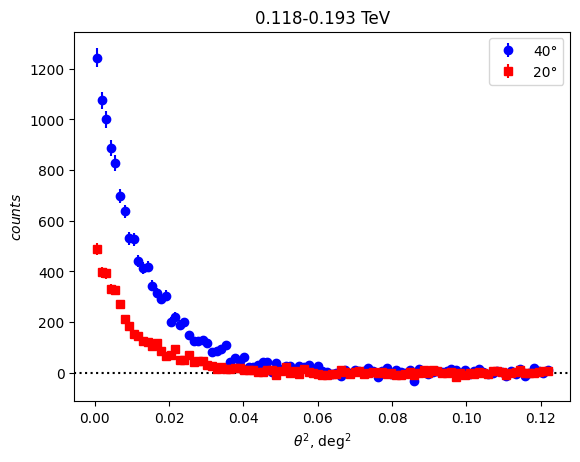

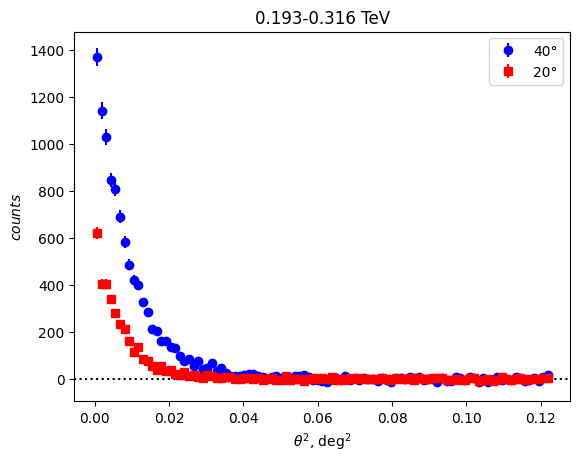

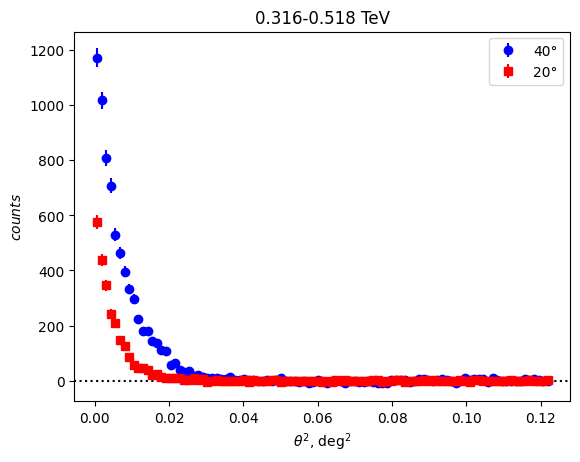

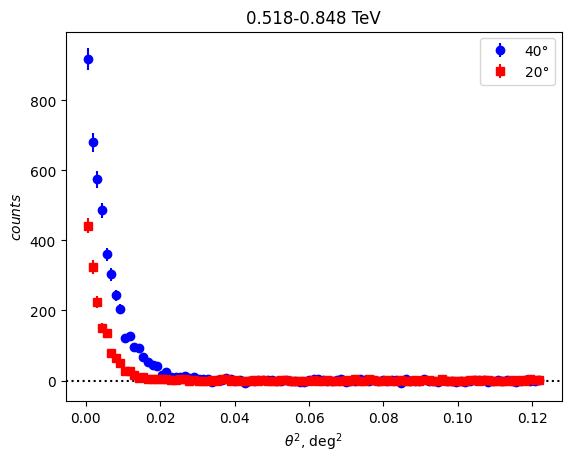

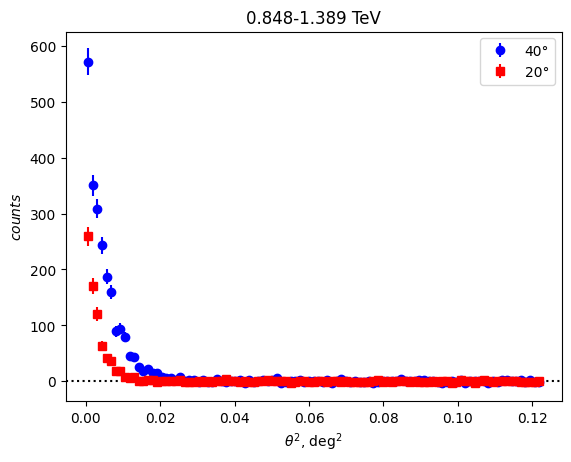

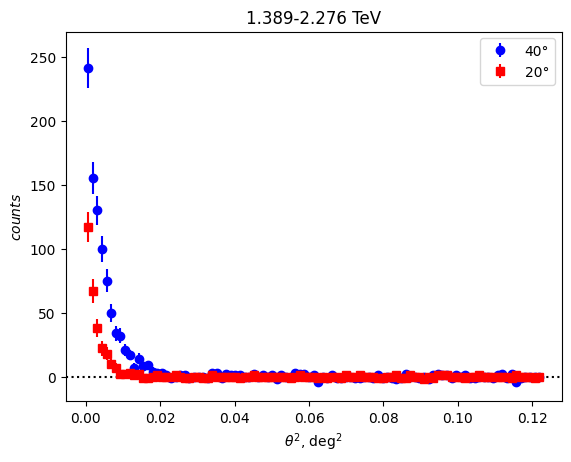

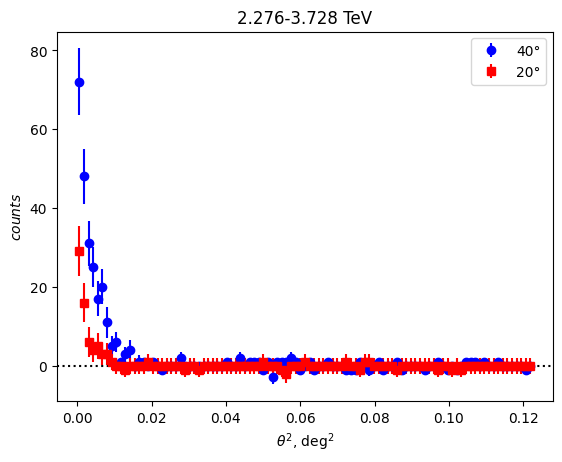

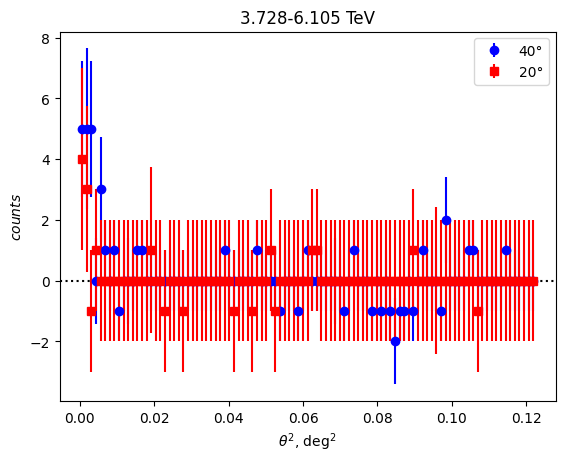

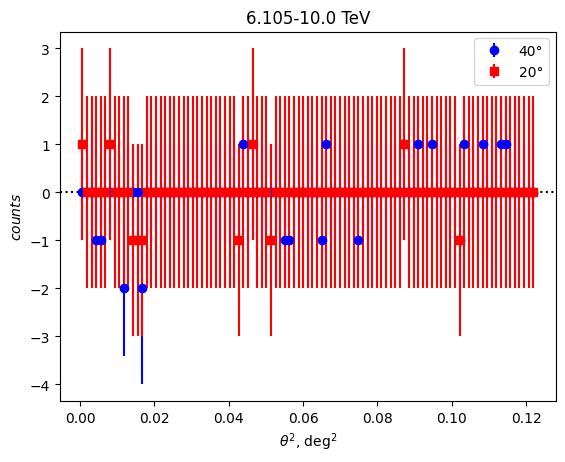

In [8]:
cts_40deg = cts_s_40deg - cts_b_40deg
cts_err_40deg = np.sqrt(np.maximum(cts_s_40deg + cts_b_40deg, 1))

cts_20deg = cts_s_20deg - cts_b_20deg
cts_err_20deg = 1 + np.sqrt(np.maximum(cts_s_20deg + cts_b_20deg, 1))

for i, ((cts_40, cts_err_40), (cts_20, cts_err_20)) in enumerate(zip(zip(cts_40deg, cts_err_40deg), zip(cts_20deg, cts_err_20deg))):
    plt.figure()
    plt.errorbar(th2, cts_40, cts_err_40, fmt='o', label='40°', color='blue')
    plt.errorbar(th2, cts_20, cts_err_20, fmt='s', label='20°', color='red')
    plt.axhline(0, color='black', linestyle='dotted')
    plt.title(str(round(e_mins[i],3)) + '-' + str(round(e_maxs[i],3)) + ' TeV')
    plt.xlabel(r'$\theta^2$, deg$^2$')
    plt.ylabel(r'$counts$')
    plt.legend()
    plt.show()

**PSF**

In [9]:
psf_hbu_40deg = irf_40deg["psf"]
psf_hbu_20deg = irf_20deg["psf"]

print(psf_hbu_40deg)
print(psf_hbu_40deg.info())
print(psf_hbu_40deg.data.shape)
# here i'm guessing the energy bins of the psf from the data printed from this cell.
psf_e_bins = np.logspace(np.log10(0.013), np.log10(199.526), 22)
psf_e_means = np.sqrt(psf_e_bins[1:]*psf_e_bins[:-1])
print(psf_e_bins)

EnergyDependentMultiGaussPSF
----------------------------

  axes      : ['energy_true', 'offset']
  shape     : (21, 6)
  ndim      : 2
  parameters: ['sigma_1', 'sigma_2', 'sigma_3', 'scale', 'ampl_2', 'ampl_3']


Summary PSF info
----------------
Theta          : size =     6, min =  0.500 deg, max =  5.500 deg
Energy hi      : size =    21, min =  0.020 TeV, max = 199.526 TeV
Energy lo      : size =    21, min =  0.013 TeV, max = 125.893 TeV
68.00 containment radius at offset = 0.0 deg and energy_true =  1.0 TeV: 0.074 deg
95.00 containment radius at offset = 0.0 deg and energy_true =  1.0 TeV: 0.121 deg
68.00 containment radius at offset = 0.0 deg and energy_true = 10.0 TeV: 0.062 deg
95.00 containment radius at offset = 0.0 deg and energy_true = 10.0 TeV: 0.100 deg

(21, 6)
[1.30000000e-02 2.05721347e-02 3.25548251e-02 5.15170959e-02
 8.15243565e-02 1.29010003e-01 2.04154705e-01 3.23069084e-01
 5.11247747e-01 8.09035193e-01 1.28027546e+00 2.02599994e+00
 3.20608797e+00 5.07354412

**UP Limits**

In [10]:
sigmas_ext_injected = np.linspace(0.05, pointing_sep_avg, 5)

In [60]:
def psf(th2, psf_params):
    sigma_1, sigma_2, sigma_3, scale, ampl_2, ampl_3 = psf_params
    
    gauss1 = np.exp(-th2 / (2 * sigma_1**2))
    gauss2 = ampl_2*np.exp(-th2 / (2 * sigma_2**2))
    gauss3 = ampl_3*np.exp(-th2 / (2 * sigma_3**2))
    return scale*(gauss1+gauss2+gauss3)
    
def H0(th2, src_ampl, psf_params):
    return src_ampl*psf(th2, psf_params)
    
def residuals_H0(params, th2, ct_injected, ct_injected_err, psf_params):
    src_ampl = params[0]
    fitted_H0 = H0(th2, src_ampl, psf_params)
    return (ct_injected - fitted_H0) / ct_injected_err
    
def ext_convoluted(th2, sigma_ext, psf_params):
    sigma_1, sigma_2, sigma_3, scale, ampl_2, ampl_3 = psf_params
    
    sigma1_conv = np.sqrt(sigma_1**2 + sigma_ext**2)
    sigma2_conv = np.sqrt(sigma_2**2 + sigma_ext**2)
    sigma3_conv = np.sqrt(sigma_3**2 + sigma_ext**2)
    c1 = sigma_1/(sigma_1**2 + sigma_ext**2)
    c2 = ampl_2*sigma_2/(sigma_2**2 + sigma_ext**2)
    c3 = ampl_3*sigma_3/(sigma_3**2 + sigma_ext**2)
    gauss1_conv = c1 * np.exp(-th2 / (2 * sigma1_conv**2))
    gauss2_conv = c2 * np.exp(-th2 / (2 * sigma2_conv**2))
    gauss3_conv = c3 * np.exp(-th2 / (2 * sigma3_conv**2))
    return gauss1_conv + gauss2_conv + gauss3_conv
    
def H1(th2, src_ampl, ext_ampl, sigma_ext, psf_params):
    return src_ampl*psf(th2, psf_params) + ext_ampl*ext_convoluted(th2, sigma_ext, psf_params)
    
def residuals_H1(params, th2, ct_injected, ct_injected_err, psf_params):
    src_ampl, ext_ampl, sigma_ext = params
    fitted_H1 = H1(
        th2,
        src_ampl,
        ext_ampl,
        sigma_ext,
        psf_params
    )
    return (ct_injected - fitted_H1) / ct_injected_err
    
def inject_extended_component(
    ct,
    ct_err,
    sigma_ext,
    ext_ampl,
    psf_params
):
    extended_component = ext_ampl * ext_convoluted(th2, sigma_ext, psf_params)
    
    if not np.all(np.isfinite(extended_component)):
        raise ValueError(
            "extended_component contains NaN or infinity: "
            f"ext_ampl={ext_ampl}, sigma_ext={sigma_ext}"
        )

    if np.any(extended_component < 0):
        raise ValueError(
            "extended_component contains negative Poisson means: "
            f"minimum={np.min(extended_component)}, "
            f"ext_ampl={ext_ampl}"
        )
    
    extended_component_poissonian = rng.poisson(extended_component)

    ct_injected = ct + extended_component_poissonian
    ct_injected_err = np.sqrt(np.maximum(ct + extended_component_poissonian, 1.0))
    
    return ct_injected, ct_injected_err

In [65]:
def compute_upper_limits(cts, cts_err, psf_hbu, rng, silent=True):
    flux_ratios = np.zeros((len(sigmas_ext_injected), len(e)))
    
    for i, (ct, ct_err) in enumerate(zip(cts, cts_err)):
        # psf_index will store the best index for accessing the PSF values form the file.
        psf_index = np.argmin(np.abs(psf_e_means - e[i]))
        psf_params = psf_hbu.data[psf_index][0]
        
        for k, sigma_ext_injected in enumerate(sigmas_ext_injected):
            max_iterations = 1200
            iteration = 0
            chi2_H1 = 0
            chi2_H0 = 0
            ext_injection_norm_factor = np.abs(np.sum(ct)/np.sum(ext_convoluted(th2, sigma_ext_injected, psf_params)))
            
            while(chi2_H0 < chi2_H1 + 4.61 and iteration < max_iterations):
                iteration += 1
                ext_ampl_injected = ext_injection_norm_factor*(iteration/400)
                
                ct_injected, ct_injected_err = inject_extended_component(ct, ct_err, sigma_ext_injected, ext_ampl_injected, psf_params)
    
                result_H0 = least_squares(
                    residuals_H0,
                    x0=[1.0],
                    args=(th2, ct_injected, ct_injected_err, psf_params),
                    bounds=([0.0], [np.inf]),
                    method="trf",
                )
                
                fitted_H0 = H0(th2, result_H0.x[0], psf_params)
                chi2_H0 = np.sum(((ct_injected - fitted_H0) / ct_injected_err) ** 2)
    
                result_H1 = least_squares(
                    residuals_H1,
                    x0=[
                        result_H0.x[0],
                        result_H0.x[0] / 10,
                        0.10,
                    ],
                    args=(th2, ct_injected, ct_injected_err, psf_params),
                    bounds=(
                        [0.0, 0.0, 1e-12],
                        [np.inf, np.inf, np.inf],
                    ),
                    method="trf",
                )
        
                fitted_H1 = H1(th2, *result_H1.x, psf_params)
                chi2_H1 = np.sum(((ct_injected - fitted_H1) / ct_injected_err) ** 2)
            
            flux_ratios[k][i] = np.sum(result_H1.x[1]*ext_convoluted(th2, result_H1.x[2], psf_params))/np.sum(fitted_H0)
    
            if not silent:
                print("----------------------------")
                print("E:", e[i])
                print("ITERATION:", iteration)
                print("theta injected =", sigma_ext_injected)
                error_percent = (np.abs(sigma_ext_injected - result_H1.x[2])/ sigma_ext_injected * 100)
                print(f"error = {error_percent:.2f}%")
                print("ext ampl injected =", ext_ampl_injected)
            
                plt.figure()
                plt.errorbar(th2, ct, ct_err)
                plt.plot(th2, ct_injected, "k:")
                plt.plot(th2, fitted_H0, "b:")
                plt.plot(th2, fitted_H1, "r:")
                plt.show()
            
    return flux_ratios

In [66]:
rng = np.random.default_rng(0)

In [67]:
flux_ratios_20deg = compute_upper_limits(cts_20deg, cts_err_20deg, psf_hbu_20deg, rng, True)

In [68]:
flux_ratios_40deg = compute_upper_limits(cts_40deg, cts_err_40deg, psf_hbu_40deg, rng, True)

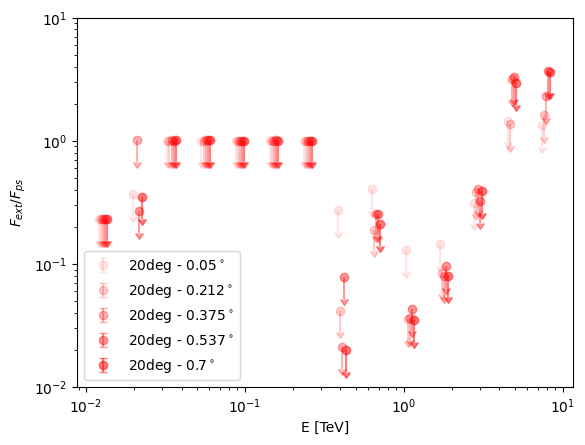

In [69]:
for i, flux_ratio_20deg in enumerate(flux_ratios_20deg):
    plt.errorbar(e*(0.95*1.03**i), flux_ratio_20deg,np.abs(flux_ratio_20deg)/3, alpha=0.1+0.1*i, uplims=True, linestyle='none',marker='o', label="20deg - "+str(round(sigmas_ext_injected[i],3))+r'$^\circ$',color='red')
plt.xscale("log")
plt.yscale("log")
plt.ylabel(r"$F_{ext}/F_{ps}$")
plt.xlabel("E [TeV]")
plt.ylim([0.01, 10])
plt.legend()

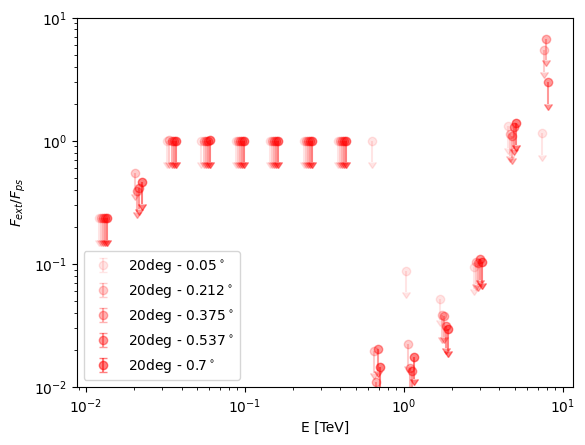

In [70]:
for i, flux_ratio_40deg in enumerate(flux_ratios_40deg):
    plt.errorbar(e*(0.95*1.03**i), flux_ratio_40deg,np.abs(flux_ratio_40deg)/3, alpha=0.1+0.1*i, uplims=True, linestyle='none',marker='o', label="20deg - "+str(round(sigmas_ext_injected[i],3))+r'$^\circ$',color='red')
plt.xscale("log")
plt.yscale("log")
plt.ylabel(r"$F_{ext}/F_{ps}$")
plt.xlabel("E [TeV]")
plt.ylim([0.01, 10])
plt.legend()